In [41]:
# Install Kaggle API
!pip -q install kaggle

import os
import json
import zipfile
from getpass import getpass

# Enter Kaggle credentials
KAGGLE_USERNAME = "username"
KAGGLE_KEY = "password"

# Create kaggle.json
os.makedirs("/root/.kaggle", exist_ok=True)

with open("/root/.kaggle/kaggle.json", "w") as f:
    json.dump(
        {
            "username": KAGGLE_USERNAME,
            "key": KAGGLE_KEY
        },
        f
    )

# Set correct permissions
os.chmod("/root/.kaggle/kaggle.json", 0o600)

# Download dataset
!kaggle datasets download -d mczielinski/bitcoin-historical-data -p /content/bitcoin_dataset --unzip

print("\nDownload Completed!\n")

# Show downloaded files
import os

for root, dirs, files in os.walk("/content/bitcoin_dataset"):
    for file in files:
        print(os.path.join(root, file))

Dataset URL: https://www.kaggle.com/datasets/mczielinski/bitcoin-historical-data
License(s): CC-BY-SA-4.0
100% 104M/104M [00:00<00:00, 178MB/s]


Download Completed!

/content/bitcoin_dataset/btcusd_1-min_data.csv


In [42]:
import pandas as pd

df = pd.read_csv("/content/bitcoin_dataset/btcusd_1-min_data.csv")

print(df.shape)
df.head()

(7668103, 6)


,Timestamp,Open,High,Low,Close,Volume
0,1325376060,4.58,4.58,4.58,4.58,0.0
1,1325376120,4.58,4.58,4.58,4.58,0.0
2,1325376180,4.58,4.58,4.58,4.58,0.0
3,1325376240,4.58,4.58,4.58,4.58,0.0
4,1325376300,4.58,4.58,4.58,4.58,0.0


## **Import Libraries and Load the Dataset**

In [43]:
# Import required libraries

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

print("Libraries imported successfully")

# Load dataset

df = pd.read_csv("/content/bitcoin_dataset/btcusd_1-min_data.csv")

print("Dataset loaded successfully")

print("\nDataset Shape")
print(df.shape)

print("\nDataset Information")
print(df.info())

print("\nFirst Five Rows")
display(df.head())

print("\nLast Five Rows")
display(df.tail())

Libraries imported successfully
Dataset loaded successfully

Dataset Shape
(7668103, 6)

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7668103 entries, 0 to 7668102
Data columns (total 6 columns):
 #   Column     Dtype  
---  ------     -----  
 0   Timestamp  int64  
 1   Open       float64
 2   High       float64
 3   Low        float64
 4   Close      float64
 5   Volume     float64
dtypes: float64(5), int64(1)
memory usage: 351.0 MB
None

First Five Rows


,Timestamp,Open,High,Low,Close,Volume
0,1325376060,4.58,4.58,4.58,4.58,0.0
1,1325376120,4.58,4.58,4.58,4.58,0.0
2,1325376180,4.58,4.58,4.58,4.58,0.0
3,1325376240,4.58,4.58,4.58,4.58,0.0
4,1325376300,4.58,4.58,4.58,4.58,0.0



Last Five Rows


,Timestamp,Open,High,Low,Close,Volume
7668098,1785461940,64886.84,64886.85,64833.62,64843.61,2.030980
7668099,1785462000,64856.19,64856.19,64843.60,64843.60,0.003269
7668100,1785462060,64854.01,64860.36,64854.01,64855.06,0.003445
7668101,1785462120,64855.06,64880.75,64851.47,64851.47,4.622754
7668102,1785462180,64842.14,64842.14,64783.55,64783.55,0.309158


### **Data Cleaning**

In [44]:
# Check dataset quality

print("Dataset Shape")
print(df.shape)

print("\nMissing Values")
print(df.isnull().sum())

print("\nDuplicate Rows")
print(df.duplicated().sum())

print("\nData Types")
print(df.dtypes)

# Convert timestamp to datetime

df["Timestamp"] = pd.to_datetime(df["Timestamp"], unit="s")

# Sort records

df = df.sort_values("Timestamp").reset_index(drop=True)

# Remove duplicate rows

rows_before = len(df)

df = df.drop_duplicates().reset_index(drop=True)

rows_after = len(df)

print("\nRows Before Cleaning")
print(rows_before)

print("\nRows After Cleaning")
print(rows_after)

print("\nDuplicate Rows Removed")
print(rows_before - rows_after)

# Remove rows with missing values

missing_before = len(df)

df = df.dropna().reset_index(drop=True)

missing_after = len(df)

print("\nRows Removed Because of Missing Values")
print(missing_before - missing_after)

# Check negative values

numeric_columns = ["Open", "High", "Low", "Close", "Volume"]

negative_counts = (df[numeric_columns] < 0).sum()

print("\nNegative Values")

print(negative_counts)

# Remove negative values if present

for column in numeric_columns:
    df = df[df[column] >= 0]

df = df.reset_index(drop=True)

print("\nFinal Dataset Shape")
print(df.shape)

print("\nFirst Five Rows")
display(df.head())

Dataset Shape
(7668103, 6)

Missing Values
Timestamp    0
Open         0
High         0
Low          0
Close        0
Volume       0
dtype: int64

Duplicate Rows
0

Data Types
Timestamp      int64
Open         float64
High         float64
Low          float64
Close        float64
Volume       float64
dtype: object

Rows Before Cleaning
7668103

Rows After Cleaning
7668103

Duplicate Rows Removed
0

Rows Removed Because of Missing Values
0

Negative Values
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64

Final Dataset Shape
(7668103, 6)

First Five Rows


,Timestamp,Open,High,Low,Close,Volume
0,2012-01-01 00:01:00,4.58,4.58,4.58,4.58,0.0
1,2012-01-01 00:02:00,4.58,4.58,4.58,4.58,0.0
2,2012-01-01 00:03:00,4.58,4.58,4.58,4.58,0.0
3,2012-01-01 00:04:00,4.58,4.58,4.58,4.58,0.0
4,2012-01-01 00:05:00,4.58,4.58,4.58,4.58,0.0


In [45]:
# Check zero values

numeric_columns = ["Open", "High", "Low", "Close", "Volume"]

print("Zero Values")

print((df[numeric_columns] == 0).sum())

# Check infinite values

print("\nInfinite Values")

print(np.isinf(df[numeric_columns]).sum())

# Remove infinite values

df = df.replace([np.inf, -np.inf], np.nan)

df = df.dropna().reset_index(drop=True)

# Remove unrealistic price values

df = df[
    (df["Open"] > 0) &
    (df["High"] > 0) &
    (df["Low"] > 0) &
    (df["Close"] > 0)
].reset_index(drop=True)

# Check High is greater than or equal to Open, Close and Low

invalid_high = df[
    (df["High"] < df["Open"]) |
    (df["High"] < df["Close"]) |
    (df["High"] < df["Low"])
]

print("\nInvalid High Values")

print(len(invalid_high))

# Check Low is less than or equal to Open, Close and High

invalid_low = df[
    (df["Low"] > df["Open"]) |
    (df["Low"] > df["Close"]) |
    (df["Low"] > df["High"])
]

print("\nInvalid Low Values")

print(len(invalid_low))

# Remove invalid records if present

df = df.drop(invalid_high.index, errors="ignore")

df = df.drop(invalid_low.index, errors="ignore")

df = df.reset_index(drop=True)

print("\nFinal Dataset Shape")

print(df.shape)

print("\nDataset Summary")

display(df.describe().round(2))

Zero Values
Open            0
High            0
Low             0
Close           0
Volume    1312365
dtype: int64

Infinite Values
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64

Invalid High Values
0

Invalid Low Values
0

Final Dataset Shape
(7668103, 6)

Dataset Summary


,Timestamp,Open,High,Low,Close,Volume
count,7668103,7668103.00,7668103.00,7668103.00,7668103.00,7668103.00
mean,2019-04-16 12:52:00.000015360,23692.09,23700.31,23683.70,23692.11,4.97
min,2012-01-01 00:01:00,3.80,3.80,3.80,3.80,0.00
25%,2015-08-24 06:26:30,458.06,458.20,457.97,458.06,0.02
50%,2019-04-16 12:52:00,8094.86,8099.98,8089.50,8094.65,0.44
75%,2022-12-07 19:17:30,38906.46,38926.79,38884.88,38906.66,2.77
max,2026-07-31 01:43:00,126202.00,126272.00,126158.00,126202.00,5853.85
std,NaN,31369.66,31378.03,31361.23,31369.68,21.59


## **Exploratory Data Analysis (EDA)**

EDA Dataset Shape
(153363, 6)


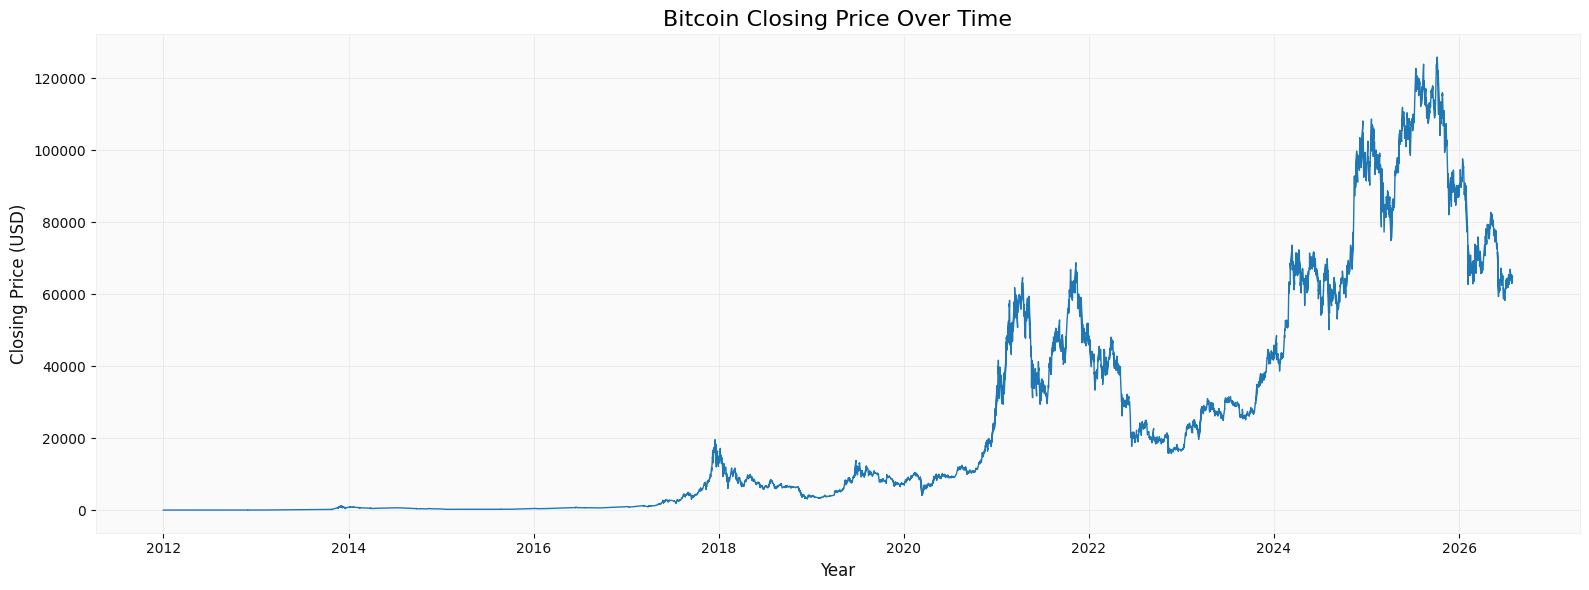

In [46]:
# Create a smaller dataset for visualisation

eda_df = df.copy()

if len(eda_df) > 100000:
    eda_df = eda_df.iloc[::50].reset_index(drop=True)

print("EDA Dataset Shape")
print(eda_df.shape)

plt.figure(figsize=(16,6))

plt.plot(
    eda_df["Timestamp"],
    eda_df["Close"],
    linewidth=1
)

plt.title("Bitcoin Closing Price Over Time", fontsize=16)

plt.xlabel("Year", fontsize=12)

plt.ylabel("Closing Price (USD)", fontsize=12)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

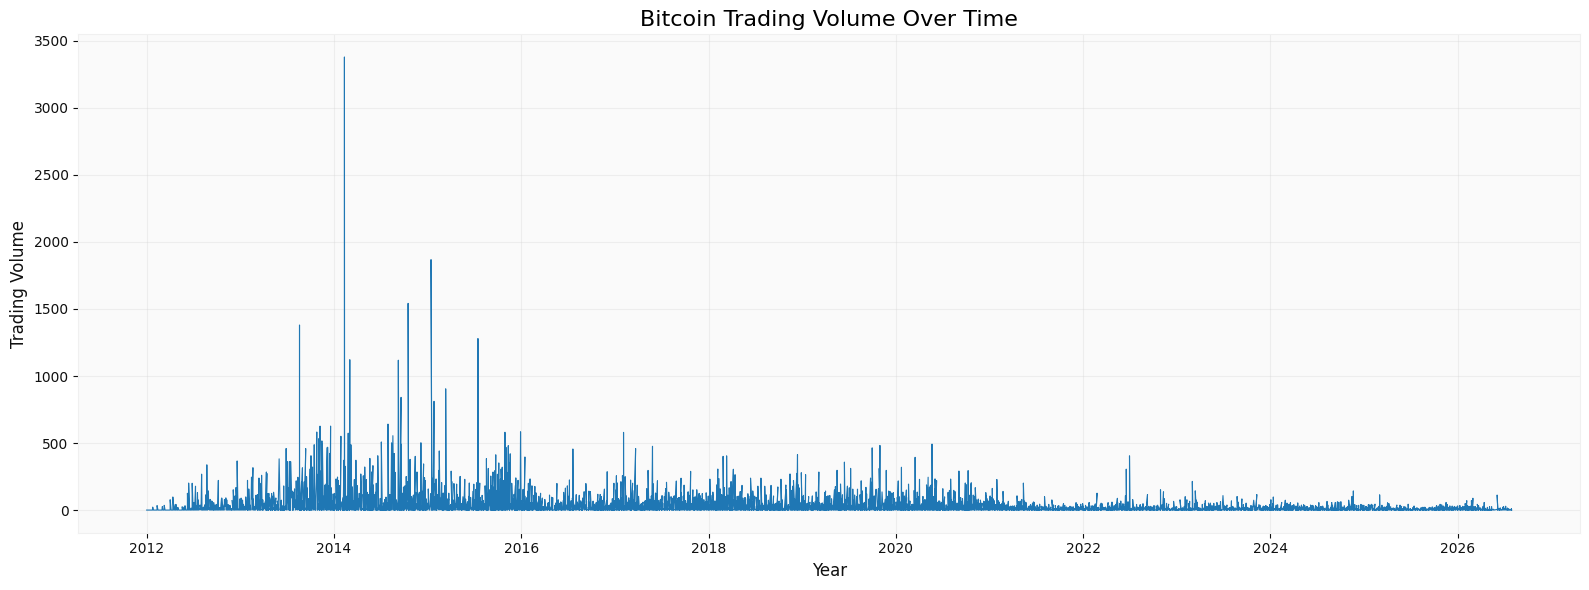

In [47]:
plt.figure(figsize=(16,6))

plt.plot(
    eda_df["Timestamp"],
    eda_df["Volume"],
    linewidth=0.8
)

plt.title("Bitcoin Trading Volume Over Time", fontsize=16)

plt.xlabel("Year", fontsize=12)

plt.ylabel("Trading Volume", fontsize=12)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

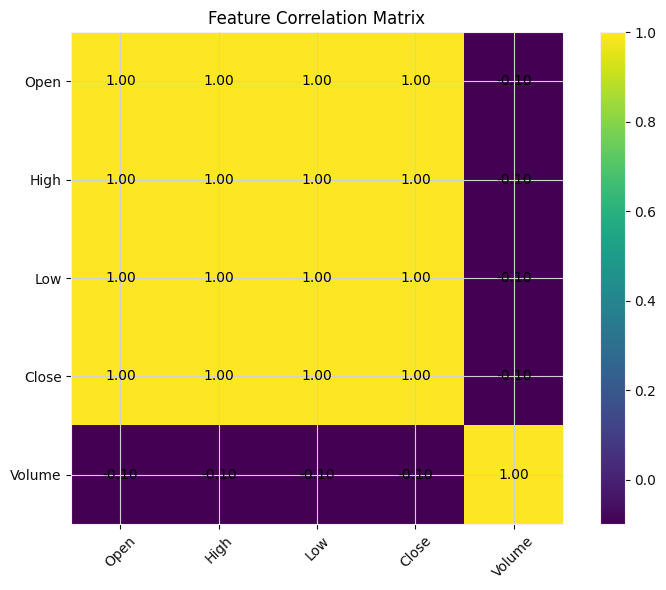

In [48]:
import matplotlib.pyplot as plt

correlation = df[["Open","High","Low","Close","Volume"]].corr()

plt.figure(figsize=(8,6))

image = plt.imshow(correlation)

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=45
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

for i in range(len(correlation.columns)):
    for j in range(len(correlation.columns)):
        plt.text(
            j,
            i,
            f"{correlation.iloc[i,j]:.2f}",
            ha="center",
            va="center",
            fontsize=10
        )

plt.colorbar(image)

plt.title("Feature Correlation Matrix")

plt.tight_layout()

plt.show()

In [49]:
!pip -q install mplfinance

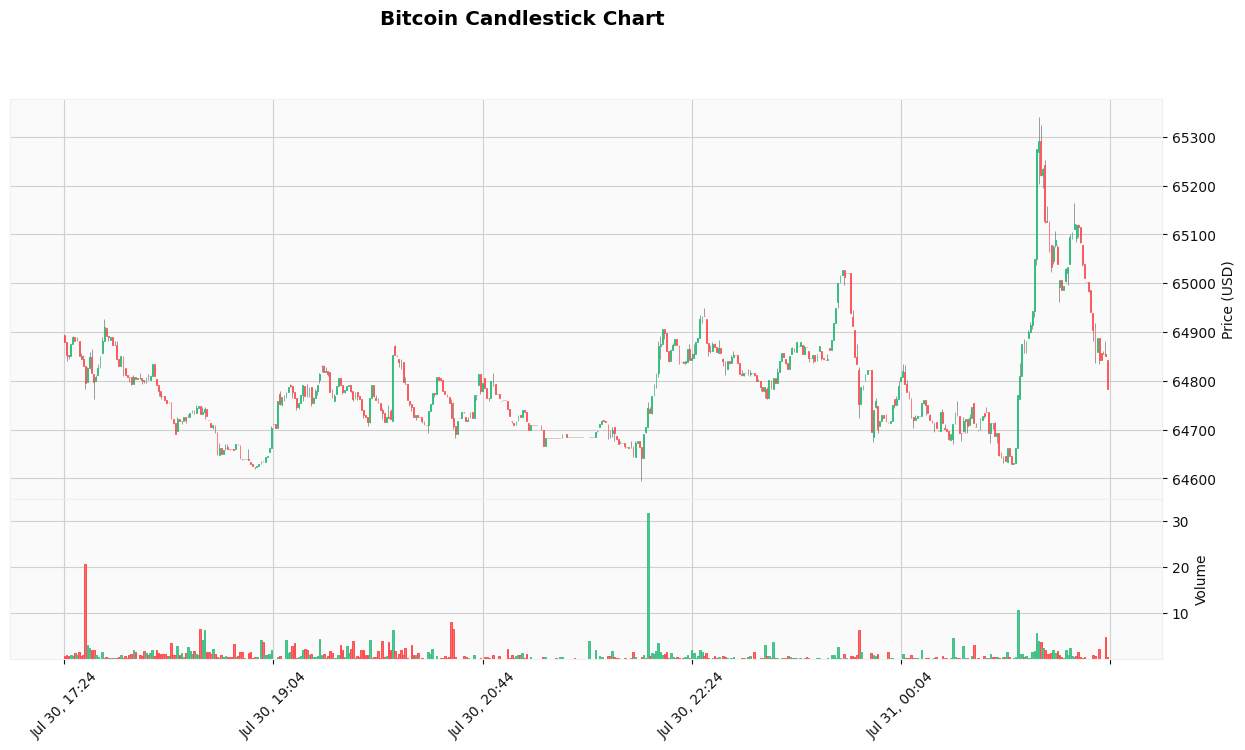

In [50]:
import mplfinance as mpf

# Select recent observations for better visibility

candlestick_df = df.tail(500).copy()

# Prepare data

candlestick_df = candlestick_df.rename(
    columns={
        "Timestamp":"Date"
    }
)

candlestick_df = candlestick_df.set_index("Date")

# Plot chart

mpf.plot(
    candlestick_df,
    type="candle",
    style="yahoo",
    volume=True,
    figsize=(16,8),
    title="Bitcoin Candlestick Chart",
    ylabel="Price (USD)",
    ylabel_lower="Volume"
)

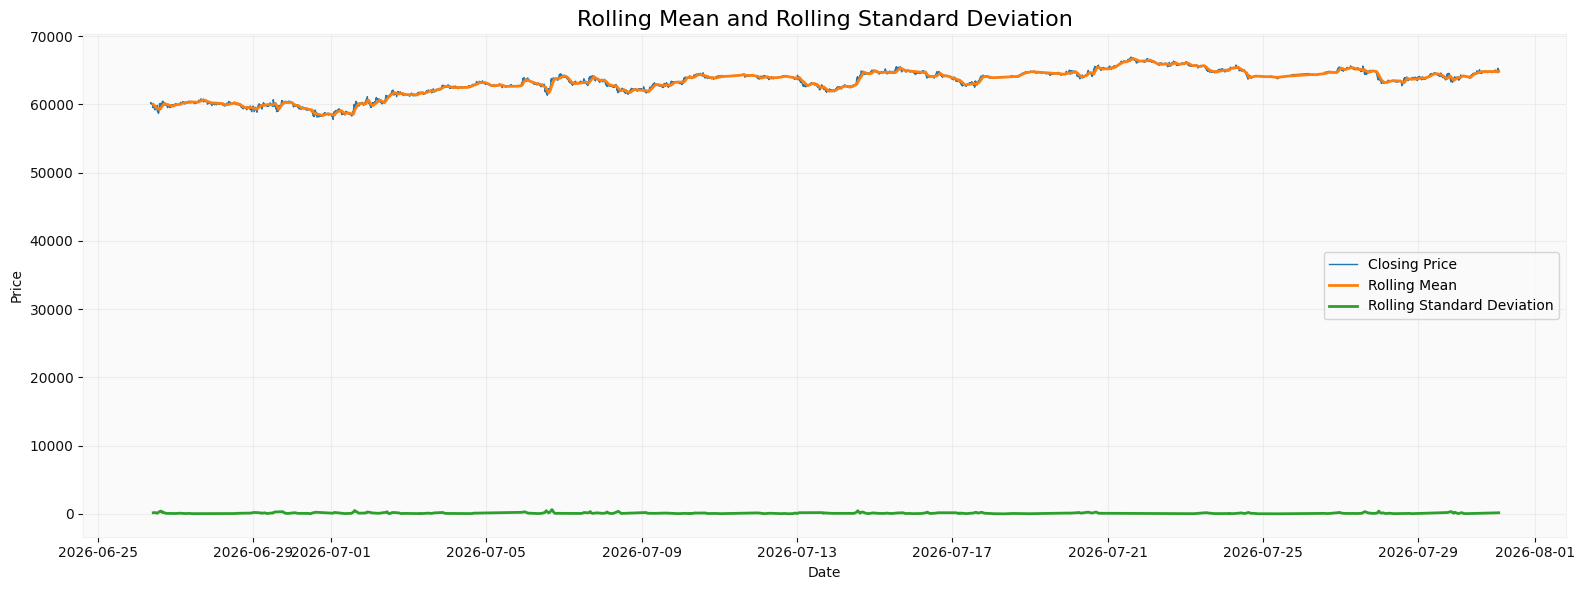

In [51]:
rolling_df = df.tail(50000).copy()

rolling_df["Rolling Mean"] = rolling_df["Close"].rolling(window=100).mean()

rolling_df["Rolling Standard Deviation"] = rolling_df["Close"].rolling(window=100).std()

plt.figure(figsize=(16,6))

plt.plot(
    rolling_df["Timestamp"],
    rolling_df["Close"],
    label="Closing Price",
    linewidth=1
)

plt.plot(
    rolling_df["Timestamp"],
    rolling_df["Rolling Mean"],
    label="Rolling Mean",
    linewidth=2
)

plt.plot(
    rolling_df["Timestamp"],
    rolling_df["Rolling Standard Deviation"],
    label="Rolling Standard Deviation",
    linewidth=2
)

plt.title("Rolling Mean and Rolling Standard Deviation", fontsize=16)

plt.xlabel("Date")

plt.ylabel("Price")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

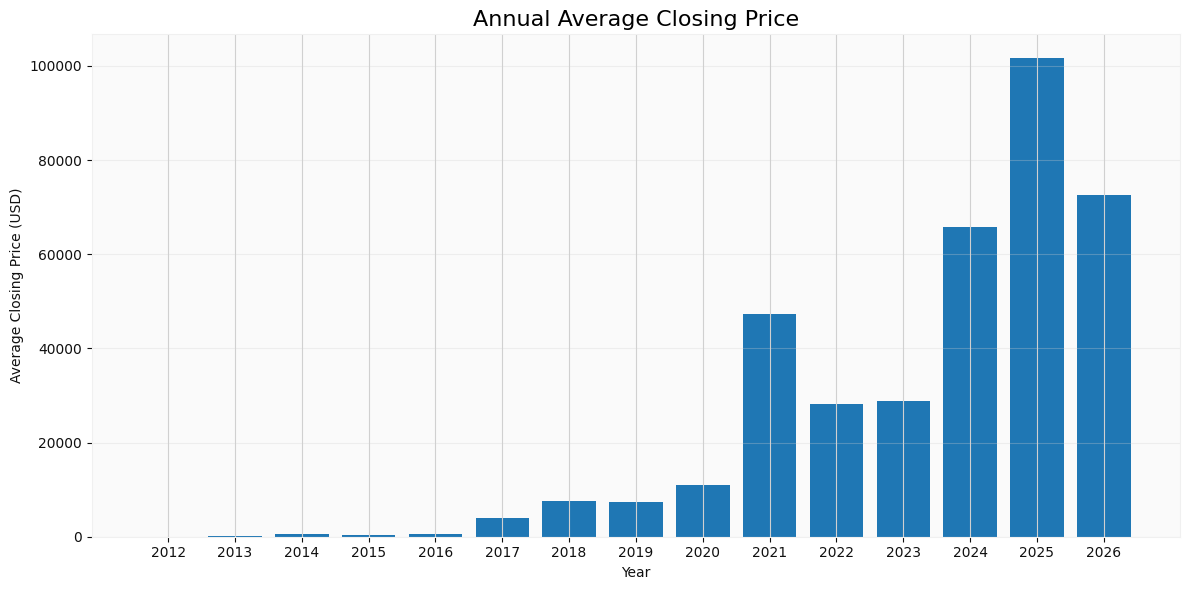

In [52]:
annual_df = df.copy()

annual_df["Year"] = annual_df["Timestamp"].dt.year

annual_average = (
    annual_df
    .groupby("Year")["Close"]
    .mean()
)

plt.figure(figsize=(12,6))

plt.bar(
    annual_average.index.astype(str),
    annual_average.values
)

plt.title("Annual Average Closing Price", fontsize=16)

plt.xlabel("Year")

plt.ylabel("Average Closing Price (USD)")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

## **Dataset-Preprocessing**

In [53]:
# Feature Engineering
# Create moving averages

df["SMA_10"] = df["Close"].rolling(10).mean()

df["SMA_20"] = df["Close"].rolling(20).mean()

# Create exponential moving averages

df["EMA_10"] = df["Close"].ewm(span=10, adjust=False).mean()

df["EMA_20"] = df["Close"].ewm(span=20, adjust=False).mean()

# Calculate Relative Strength Index

price_change = df["Close"].diff()

gain = price_change.where(price_change > 0, 0)

loss = -price_change.where(price_change < 0, 0)

average_gain = gain.rolling(14).mean()

average_loss = loss.rolling(14).mean()

relative_strength = average_gain / average_loss

df["RSI_14"] = 100 - (100 / (1 + relative_strength))

# Calculate MACD

ema_fast = df["Close"].ewm(span=12, adjust=False).mean()

ema_slow = df["Close"].ewm(span=26, adjust=False).mean()

df["MACD"] = ema_fast - ema_slow

df["MACD_Signal"] = df["MACD"].ewm(span=9, adjust=False).mean()

# Calculate Bollinger Bands

rolling_mean = df["Close"].rolling(20).mean()

rolling_std = df["Close"].rolling(20).std()

df["Bollinger_Upper"] = rolling_mean + (2 * rolling_std)

df["Bollinger_Lower"] = rolling_mean - (2 * rolling_std)

# Create return feature

df["Return"] = df["Close"].pct_change()

# Create volatility feature

df["Volatility"] = df["Return"].rolling(20).std()

# Create price difference features

df["High_Low_Difference"] = df["High"] - df["Low"]

df["Open_Close_Difference"] = df["Open"] - df["Close"]

# Remove rows created by rolling calculations

df = df.dropna().reset_index(drop=True)

print("Dataset Shape")

print(df.shape)

print("\nColumns")

print(df.columns.tolist())

print("\nFirst Five Rows")

display(df.head())

Dataset Shape
(7196995, 19)

Columns
['Timestamp', 'Open', 'High', 'Low', 'Close', 'Volume', 'SMA_10', 'SMA_20', 'EMA_10', 'EMA_20', 'RSI_14', 'MACD', 'MACD_Signal', 'Bollinger_Upper', 'Bollinger_Lower', 'Return', 'Volatility', 'High_Low_Difference', 'Open_Close_Difference']

First Five Rows


,Timestamp,Open,High,Low,Close,Volume,SMA_10,SMA_20,EMA_10,EMA_20,RSI_14,MACD,MACD_Signal,Bollinger_Upper,Bollinger_Lower,Return,Volatility,High_Low_Difference,Open_Close_Difference
0,2012-01-01 15:28:00,4.84,4.84,4.84,4.84,10.0,4.606,4.593,4.627273,4.604762,100.0,0.020741,0.004148,4.709276,4.476724,0.056769,0.012694,0.0,0.0
1,2012-01-01 15:29:00,4.84,4.84,4.84,4.84,0.0,4.632,4.606,4.665950,4.627166,100.0,0.036754,0.010669,4.766053,4.445947,0.000000,0.012694,0.0,0.0
2,2012-01-01 15:30:00,4.84,4.84,4.84,4.84,0.0,4.658,4.619,4.697596,4.647435,100.0,0.048882,0.018312,4.809501,4.428499,0.000000,0.012694,0.0,0.0
3,2012-01-01 15:31:00,4.84,4.84,4.84,4.84,0.0,4.684,4.632,4.723487,4.665775,100.0,0.057826,0.026215,4.845403,4.418597,0.000000,0.012694,0.0,0.0
4,2012-01-01 15:32:00,4.84,4.84,4.84,4.84,0.0,4.710,4.645,4.744672,4.682368,100.0,0.064175,0.033807,4.876016,4.413984,0.000000,0.012694,0.0,0.0


## **Model Development**

In [54]:
# Select the latest observations

model_df = df.tail(500000).copy()

model_df = model_df.reset_index(drop=True)

print("Dataset Shape")

print(model_df.shape)

print("\nFirst Five Rows")

display(model_df.head())

print("\nLast Five Rows")

display(model_df.tail())

Dataset Shape
(500000, 19)

First Five Rows


,Timestamp,Open,High,Low,Close,Volume,SMA_10,SMA_20,EMA_10,EMA_20,RSI_14,MACD,MACD_Signal,Bollinger_Upper,Bollinger_Lower,Return,Volatility,High_Low_Difference,Open_Close_Difference
0,2025-08-17 19:54:00,117658.0,117673.0,117658.0,117673.0,0.252005,117626.7,117631.90,117640.628708,117648.396603,66.532258,-17.022744,-27.606912,117702.547814,117561.252186,0.000127,0.000213,15.0,-15.0
1,2025-08-17 19:55:00,117673.0,117703.0,117673.0,117703.0,0.304716,117639.1,117633.45,117651.968943,117653.596926,68.441065,-10.760404,-24.237610,117708.992863,117557.907137,0.000255,0.000219,30.0,-30.0
2,2025-08-17 19:56:00,117702.0,117702.0,117666.0,117666.0,0.754264,117648.4,117631.80,117654.520044,117654.778171,54.887218,-8.682953,-21.126679,117702.607656,117560.992344,-0.000314,0.000224,36.0,36.0
3,2025-08-17 19:57:00,117627.0,117631.0,117627.0,117631.0,0.260205,117650.4,117629.00,117650.243673,117652.513584,55.094340,-9.748392,-18.851021,117694.873866,117563.126134,-0.000297,0.000233,4.0,-4.0
4,2025-08-17 19:58:00,117630.0,117632.0,117630.0,117632.0,0.104996,117649.6,117628.55,117646.926641,117650.559909,58.102767,-10.392273,-17.159272,117694.201295,117562.898705,0.000009,0.000216,2.0,-2.0



Last Five Rows


,Timestamp,Open,High,Low,Close,Volume,SMA_10,SMA_20,EMA_10,EMA_20,RSI_14,MACD,MACD_Signal,Bollinger_Upper,Bollinger_Lower,Return,Volatility,High_Low_Difference,Open_Close_Difference
499995,2026-07-31 01:39:00,64886.84,64886.85,64833.62,64843.61,2.030980,64955.173,65007.7670,64937.835504,64977.811117,15.515631,-30.058993,1.232668,65180.943197,64834.590803,-6.663908e-04,0.000467,53.23,43.23
499996,2026-07-31 01:40:00,64856.19,64856.19,64843.60,64843.60,0.003269,64931.192,64999.6195,64920.701776,64965.029106,13.045322,-36.386570,-6.291179,65187.725945,64811.513055,-1.542172e-07,0.000461,12.59,12.59
499997,2026-07-31 01:41:00,64854.01,64860.36,64854.01,64855.06,0.003445,64912.832,64993.0900,64908.766908,64954.555858,11.757955,-40.015223,-13.035988,65191.994251,64794.185749,1.767329e-04,0.000463,6.35,-1.05
499998,2026-07-31 01:42:00,64855.06,64880.75,64851.47,64851.47,4.622754,64896.929,64985.9540,64898.349288,64944.738157,11.710914,-42.688553,-18.966501,65194.689715,64777.218285,-5.535420e-05,0.000460,29.28,3.59
499999,2026-07-31 01:43:00,64842.14,64842.14,64783.55,64783.55,0.309158,64875.046,64973.6895,64877.476690,64929.386904,9.911239,-49.714683,-25.116137,65199.907911,64747.471089,-1.047316e-03,0.000479,58.59,58.59


### **Create Target Variable**

In [55]:
# Create target variable

model_df["Target"] = model_df["Close"].shift(-1)

# Remove the last row

model_df = model_df.dropna().reset_index(drop=True)

print("Dataset Shape")

print(model_df.shape)

print("\nFirst Five Rows")

display(model_df.head())

Dataset Shape
(499999, 20)

First Five Rows


,Timestamp,Open,High,Low,Close,Volume,SMA_10,SMA_20,EMA_10,EMA_20,RSI_14,MACD,MACD_Signal,Bollinger_Upper,Bollinger_Lower,Return,Volatility,High_Low_Difference,Open_Close_Difference,Target
0,2025-08-17 19:54:00,117658.0,117673.0,117658.0,117673.0,0.252005,117626.7,117631.90,117640.628708,117648.396603,66.532258,-17.022744,-27.606912,117702.547814,117561.252186,0.000127,0.000213,15.0,-15.0,117703.0
1,2025-08-17 19:55:00,117673.0,117703.0,117673.0,117703.0,0.304716,117639.1,117633.45,117651.968943,117653.596926,68.441065,-10.760404,-24.237610,117708.992863,117557.907137,0.000255,0.000219,30.0,-30.0,117666.0
2,2025-08-17 19:56:00,117702.0,117702.0,117666.0,117666.0,0.754264,117648.4,117631.80,117654.520044,117654.778171,54.887218,-8.682953,-21.126679,117702.607656,117560.992344,-0.000314,0.000224,36.0,36.0,117631.0
3,2025-08-17 19:57:00,117627.0,117631.0,117627.0,117631.0,0.260205,117650.4,117629.00,117650.243673,117652.513584,55.094340,-9.748392,-18.851021,117694.873866,117563.126134,-0.000297,0.000233,4.0,-4.0,117632.0
4,2025-08-17 19:58:00,117630.0,117632.0,117630.0,117632.0,0.104996,117649.6,117628.55,117646.926641,117650.559909,58.102767,-10.392273,-17.159272,117694.201295,117562.898705,0.000009,0.000216,2.0,-2.0,117648.0


### **Split Features and Target**

In [56]:
from sklearn.model_selection import train_test_split

# Select input features

X = model_df.drop(columns=["Timestamp", "Target"])

# Select target

y = model_df["Target"]

# Split dataset without shuffling for time series

split_index = int(len(model_df) * 0.8)

X_train = X.iloc[:split_index]

X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]

y_test = y.iloc[split_index:]

print("Training Feature Shape")
print(X_train.shape)

print("\nTesting Feature Shape")
print(X_test.shape)

print("\nTraining Target Shape")
print(y_train.shape)

print("\nTesting Target Shape")
print(y_test.shape)

Training Feature Shape
(399999, 18)

Testing Feature Shape
(100000, 18)

Training Target Shape
(399999,)

Testing Target Shape
(100000,)


## **Standardize Features**

In [57]:
from sklearn.preprocessing import StandardScaler

# Scale input features

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Training Feature Shape")

print(X_train_scaled.shape)

print("\nTesting Feature Shape")

print(X_test_scaled.shape)

Training Feature Shape
(399999, 18)

Testing Feature Shape
(100000, 18)


## **Train Random Forest Model**

In [58]:
# Select 300000 records

train_df = model_df.tail(300000).copy()

train_df = train_df.reset_index(drop=True)

# Select features

X = train_df.drop(columns=["Timestamp", "Target"])

# Select target

y = train_df["Target"]

# Split dataset

split_index = int(len(train_df) * 0.8)

X_train = X.iloc[:split_index]

X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]

y_test = y.iloc[split_index:]

print("Training Feature Shape")

print(X_train.shape)

print("\nTesting Feature Shape")

print(X_test.shape)

print("\nTraining Target Shape")

print(y_train.shape)

print("\nTesting Target Shape")

print(y_test.shape)

Training Feature Shape
(240000, 18)

Testing Feature Shape
(60000, 18)

Training Target Shape
(240000,)

Testing Target Shape
(60000,)


In [59]:
from sklearn.ensemble import RandomForestRegressor

# Train Random Forest model

random_forest = RandomForestRegressor(
    n_estimators=30,
    max_depth=12,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

random_forest.fit(X_train, y_train)

# Predict on testing data

rf_predictions = random_forest.predict(X_test)

print("Random Forest Model Trained Successfully")

print("\nNumber of Predictions")

print("\nFirst Ten Predictions")

print(rf_predictions[:10])

Random Forest Model Trained Successfully

Number of Predictions

First Ten Predictions
[62392.58247955 62375.12768959 62371.39017927 62360.74410059
 62329.17593757 62321.54593682 62314.80305326 62320.27674203
 62314.87734393 62323.76801957]


In [60]:
import pandas as pd

# Save Random Forest results

rf_results = pd.DataFrame()

rf_results["Actual"] = y_test.values

rf_results["Predicted"] = rf_predictions

rf_results["Timestamp"] = train_df.iloc[split_index:]["Timestamp"].values

print("Random Forest Results Shape")

print(rf_results.shape)

print("\nFirst Five Rows")

display(rf_results.head())

Random Forest Results Shape
(60000, 3)

First Five Rows


,Actual,Predicted,Timestamp
0,62364.38,62392.582480,2026-06-19 09:43:00
1,62358.13,62375.127690,2026-06-19 09:44:00
2,62350.62,62371.390179,2026-06-19 09:45:00
3,62331.96,62360.744101,2026-06-19 09:46:00
4,62321.41,62329.175938,2026-06-19 09:47:00


In [61]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    r2_score
)

import numpy as np
import pandas as pd

# Calculate evaluation metrics

rf_mae = mean_absolute_error(y_test, rf_predictions)

rf_mse = mean_squared_error(y_test, rf_predictions)

rf_rmse = np.sqrt(rf_mse)

rf_mape = mean_absolute_percentage_error(y_test, rf_predictions)

rf_r2 = r2_score(y_test, rf_predictions)

# Save evaluation results

rf_metrics = pd.DataFrame({
    "Metric": [
        "MAE",
        "MSE",
        "RMSE",
        "MAPE",
        "R2 Score"
    ],
    "Value": [
        rf_mae,
        rf_mse,
        rf_rmse,
        rf_mape,
        rf_r2
    ]
})

print("Random Forest Evaluation Results")

display(rf_metrics)

Random Forest Evaluation Results


,Metric,Value
0,MAE,44.014985
1,MSE,17866.811816
2,RMSE,133.666794
3,MAPE,0.000726
4,R2 Score,0.994958


## **Train XGBoost Model**

In [62]:
from xgboost import XGBRegressor

# Train XGBoost model

xgboost_model = XGBRegressor(
    n_estimators=30,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgboost_model.fit(X_train, y_train)

# Predict on testing data

xgb_predictions = xgboost_model.predict(X_test)

print("XGBoost Model Trained Successfully")

print("\nNumber of Predictions")

print("\nFirst Ten Predictions")

print(xgb_predictions[:10])

XGBoost Model Trained Successfully

Number of Predictions

First Ten Predictions
[62977.973 62977.973 62977.973 62977.973 62977.973 62977.973 62901.43
 62901.43  62977.973 62901.43 ]


In [63]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    r2_score
)

import numpy as np
import pandas as pd

# Calculate evaluation metrics

xgb_mae = mean_absolute_error(y_test, xgb_predictions)

xgb_mse = mean_squared_error(y_test, xgb_predictions)

xgb_rmse = np.sqrt(xgb_mse)

xgb_mape = mean_absolute_percentage_error(y_test, xgb_predictions)

xgb_r2 = r2_score(y_test, xgb_predictions)

# Save evaluation results

xgb_metrics = pd.DataFrame({
    "Metric": [
        "MAE",
        "MSE",
        "RMSE",
        "MAPE",
        "R2 Score"
    ],
    "Value": [
        xgb_mae,
        xgb_mse,
        xgb_rmse,
        xgb_mape,
        xgb_r2
    ]
})

print("XGBoost Evaluation Results")

display(xgb_metrics)

XGBoost Evaluation Results


,Metric,Value
0,MAE,633.064347
1,MSE,602560.133512
2,RMSE,776.247469
3,MAPE,0.010219
4,R2 Score,0.829943


## **Prepare Data for LSTM**

In [64]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# Scale features

feature_scaler = MinMaxScaler()

X_train_scaled = feature_scaler.fit_transform(X_train)

X_test_scaled = feature_scaler.transform(X_test)

# Scale target

target_scaler = MinMaxScaler()

y_train_scaled = target_scaler.fit_transform(
    y_train.values.reshape(-1, 1)
)

y_test_scaled = target_scaler.transform(
    y_test.values.reshape(-1, 1)
)

# Reshape for LSTM

X_train_lstm = X_train_scaled.reshape(
    X_train_scaled.shape[0],
    1,
    X_train_scaled.shape[1]
)

X_test_lstm = X_test_scaled.reshape(
    X_test_scaled.shape[0],
    1,
    X_test_scaled.shape[1]
)

print("Training Shape")

print(X_train_lstm.shape)

print("\nTesting Shape")

print(X_test_lstm.shape)

Training Shape
(240000, 1, 18)

Testing Shape
(60000, 1, 18)


## **Train LSTM Model**

In [65]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Build LSTM model

lstm_model = Sequential()

lstm_model.add(
    LSTM(
        64,
        input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2]),
        return_sequences=False
    )
)

lstm_model.add(Dropout(0.2))

lstm_model.add(Dense(32, activation="relu"))

lstm_model.add(Dense(1))

# Compile model

lstm_model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

# Stop training when validation loss stops improving

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

# Train model

history = lstm_model.fit(
    X_train_lstm,
    y_train_scaled,
    validation_split=0.2,
    epochs=5,
    batch_size=256,
    callbacks=[early_stop],
    verbose=1
)

# Predict

lstm_predictions_scaled = lstm_model.predict(X_test_lstm)

lstm_predictions = target_scaler.inverse_transform(
    lstm_predictions_scaled
).flatten()

print("LSTM Model Trained Successfully")

print("\nNumber of Predictions")

print(len(lstm_predictions))

print("\nFirst Ten Predictions")

print(lstm_predictions[:10])

Epoch 1/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - loss: 0.0050 - mae: 0.0325 - val_loss: 1.5599e-04 - val_mae: 0.0105
Epoch 2/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 3.7089e-04 - mae: 0.0133 - val_loss: 5.2154e-04 - val_mae: 0.0192
Epoch 3/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 2.2366e-04 - mae: 0.0104 - val_loss: 5.8081e-04 - val_mae: 0.0195
Epoch 4/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 1.4935e-04 - mae: 0.0083 - val_loss: 7.1805e-04 - val_mae: 0.0216
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step
LSTM Model Trained Successfully

Number of Predictions
60000

First Ten Predictions
[62681.984 62621.254 62611.09  62601.12  62621.008 62602.63  62615.75
 62575.586 62579.086 62567.652]


In [66]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    r2_score
)

import numpy as np
import pandas as pd

# Calculate evaluation metrics

lstm_mae = mean_absolute_error(y_test, lstm_predictions)

lstm_mse = mean_squared_error(y_test, lstm_predictions)

lstm_rmse = np.sqrt(lstm_mse)

lstm_mape = mean_absolute_percentage_error(y_test, lstm_predictions)

lstm_r2 = r2_score(y_test, lstm_predictions)

# Save evaluation results

lstm_metrics = pd.DataFrame({
    "Metric": [
        "MAE",
        "MSE",
        "RMSE",
        "MAPE",
        "R2 Score"
    ],
    "Value": [
        lstm_mae,
        lstm_mse,
        lstm_rmse,
        lstm_mape,
        lstm_r2
    ]
})

print("LSTM Evaluation Results")

display(lstm_metrics)

LSTM Evaluation Results


,Metric,Value
0,MAE,409.764340
1,MSE,493732.319218
2,RMSE,702.660885
3,MAPE,0.006749
4,R2 Score,0.860657


## **Compare Model Performance**

In [67]:
import pandas as pd

# Create comparison table

model_comparison = pd.DataFrame({

    "Model": [
        "Random Forest",
        "XGBoost",
        "LSTM"
    ],

    "MAE": [
        rf_mae,
        xgb_mae,
        lstm_mae
    ],

    "MSE": [
        rf_mse,
        xgb_mse,
        lstm_mse
    ],

    "RMSE": [
        rf_rmse,
        xgb_rmse,
        lstm_rmse
    ],

    "MAPE": [
        rf_mape,
        xgb_mape,
        lstm_mape
    ],

    "R2 Score": [
        rf_r2,
        xgb_r2,
        lstm_r2
    ]

})

print("Model Performance Comparison")

display(model_comparison)

Model Performance Comparison


,Model,MAE,MSE,RMSE,MAPE,R2 Score
0,Random Forest,44.014985,17866.811816,133.666794,0.000726,0.994958
1,XGBoost,633.064347,602560.133512,776.247469,0.010219,0.829943
2,LSTM,409.764340,493732.319218,702.660885,0.006749,0.860657


## **Model Evaluation Plots**

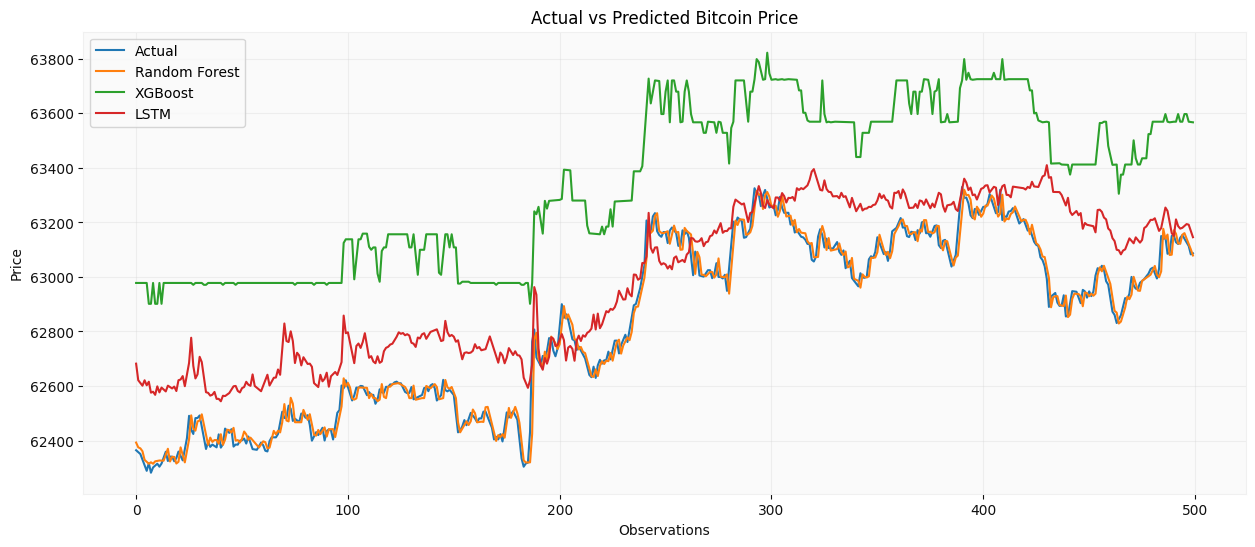

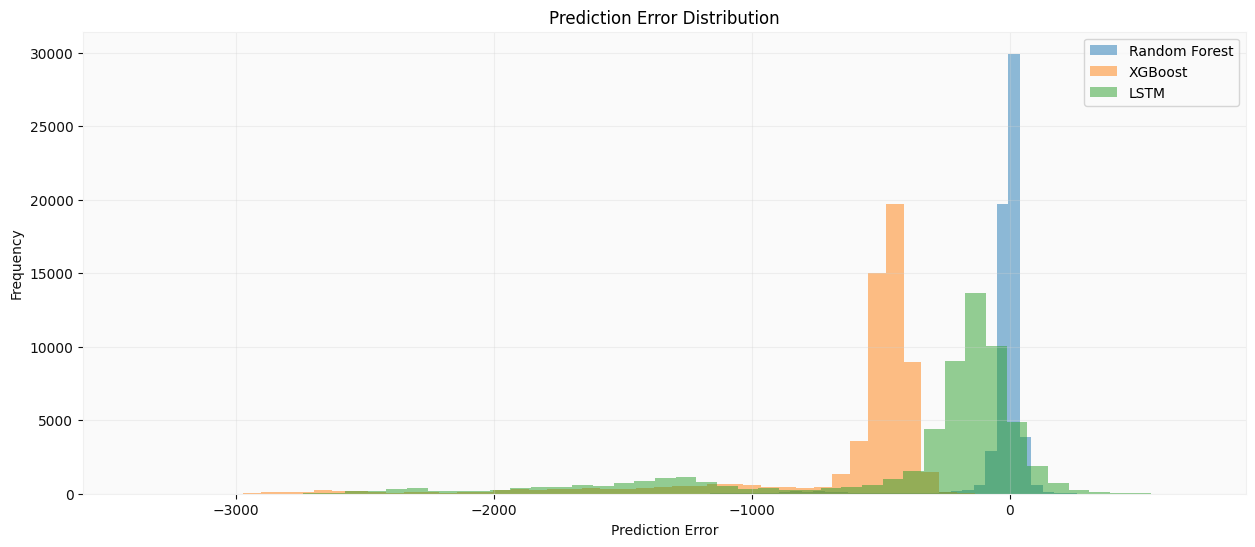

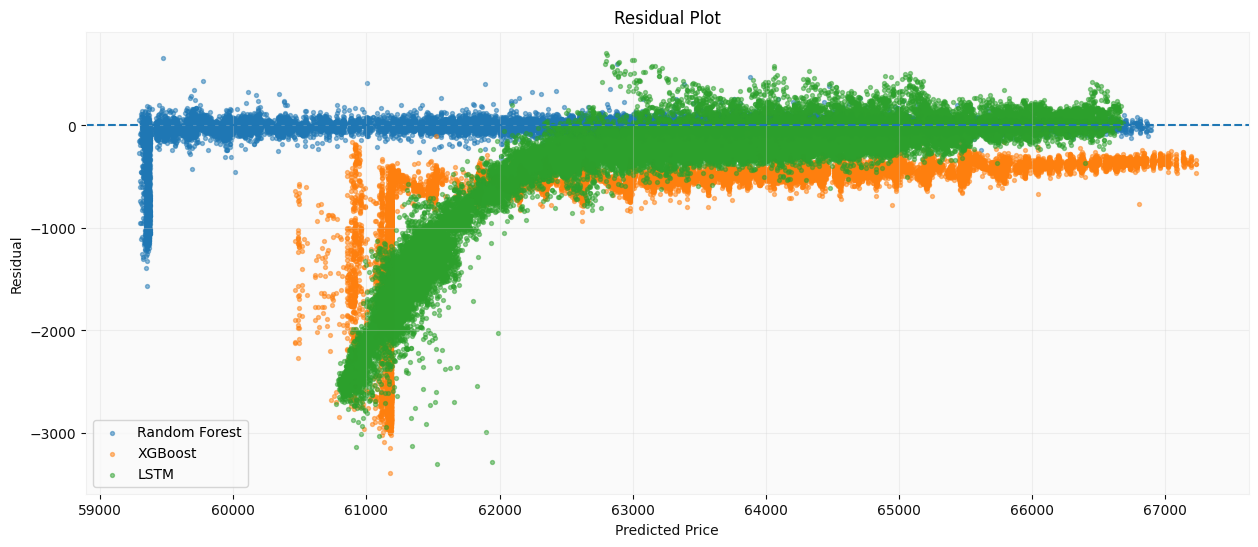

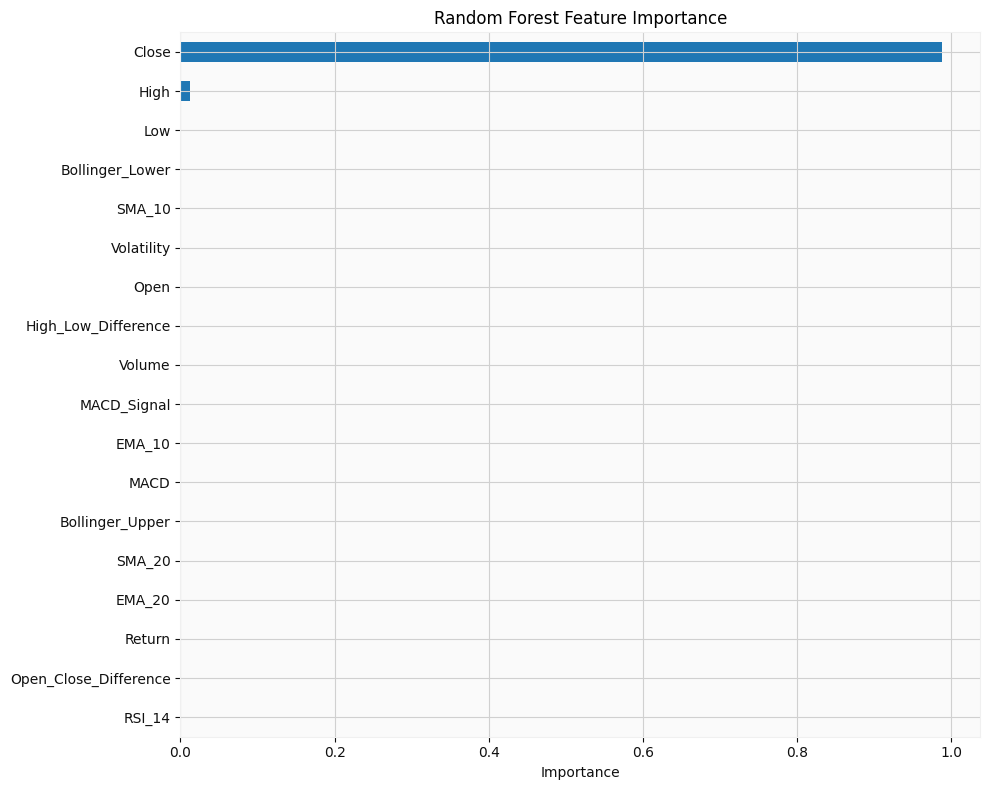

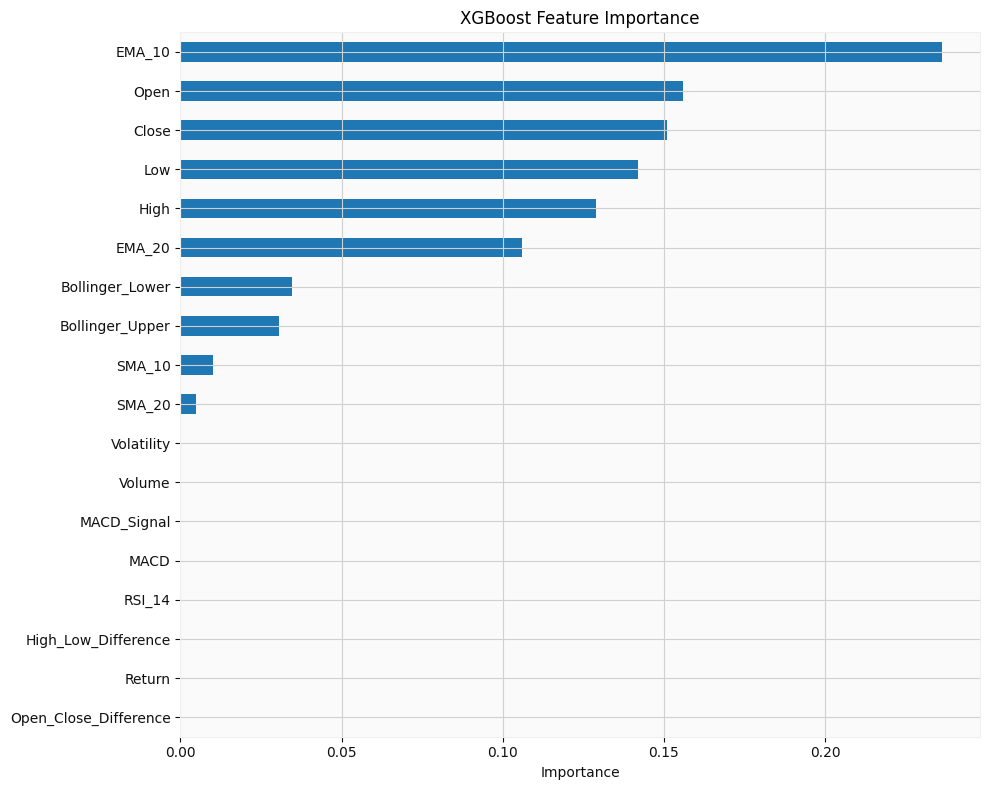

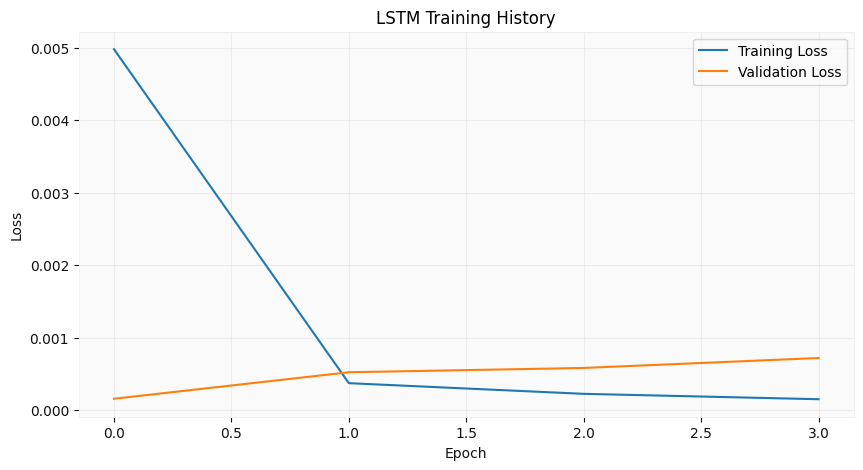

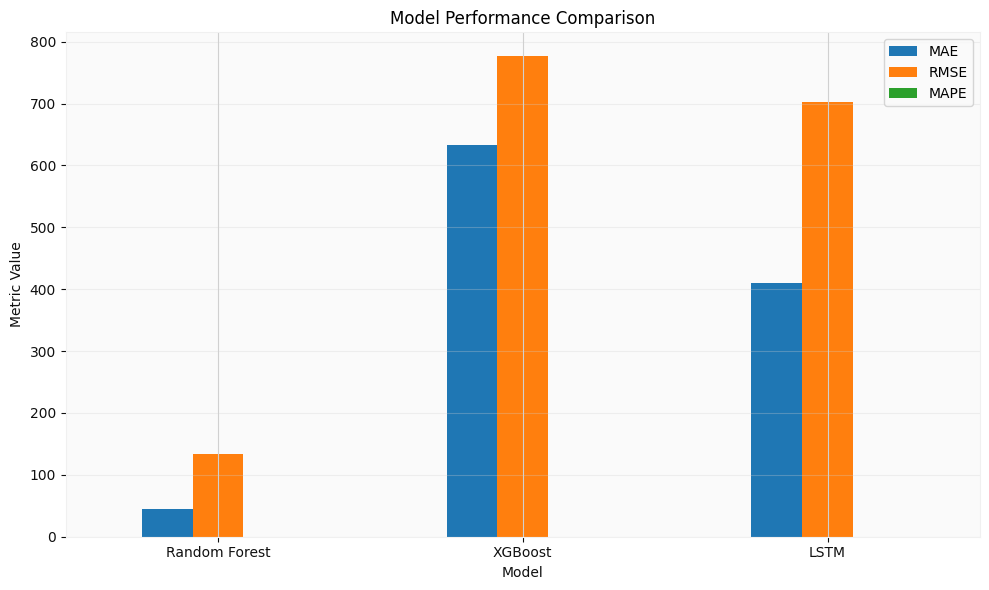

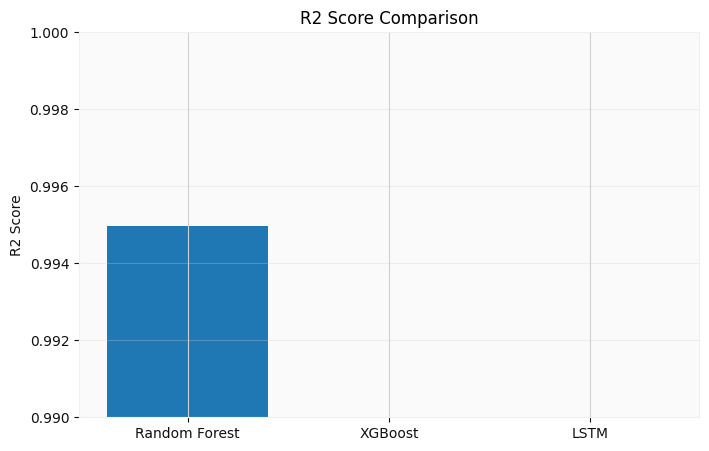

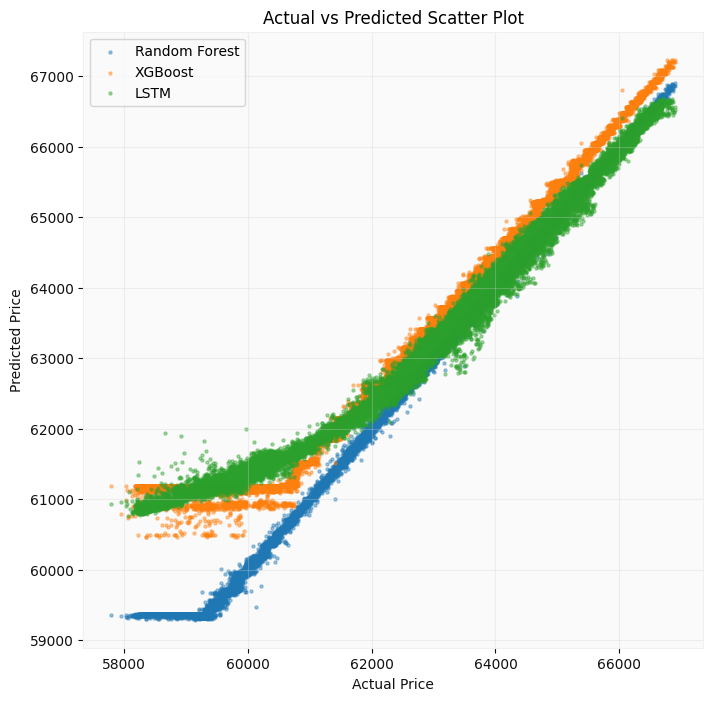

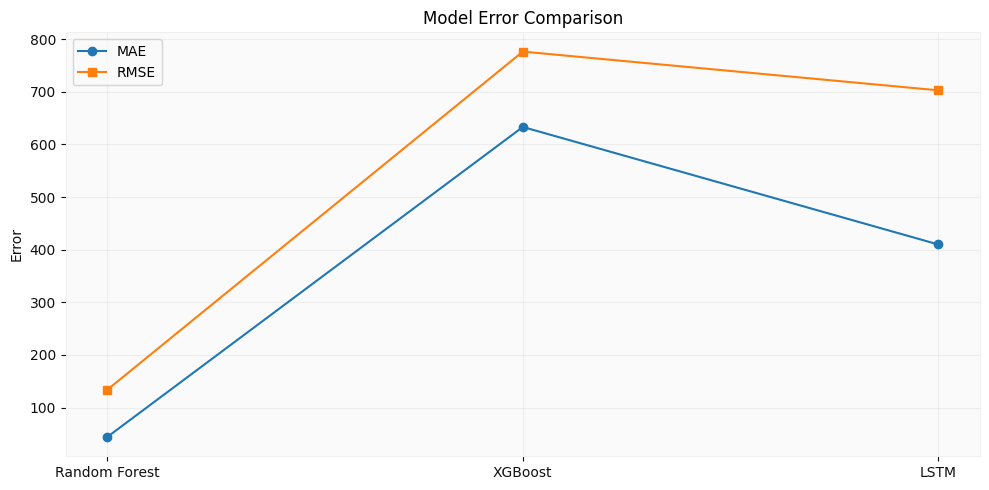

In [68]:

# Actual vs Predicted Price
import matplotlib.pyplot as plt

plt.figure(figsize=(15,6))

plt.plot(y_test.values[:500], label="Actual")

plt.plot(rf_predictions[:500], label="Random Forest")

plt.plot(xgb_predictions[:500], label="XGBoost")

plt.plot(lstm_predictions[:500], label="LSTM")

plt.title("Actual vs Predicted Bitcoin Price")

plt.xlabel("Observations")

plt.ylabel("Price")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

# Prediction Error Distribution
rf_error = y_test.values - rf_predictions
xgb_error = y_test.values - xgb_predictions
lstm_error = y_test.values - lstm_predictions

plt.figure(figsize=(15,6))

plt.hist(rf_error, bins=50, alpha=0.5, label="Random Forest")

plt.hist(xgb_error, bins=50, alpha=0.5, label="XGBoost")

plt.hist(lstm_error, bins=50, alpha=0.5, label="LSTM")

plt.title("Prediction Error Distribution")

plt.xlabel("Prediction Error")

plt.ylabel("Frequency")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

# Residual Plot
plt.figure(figsize=(15,6))

plt.scatter(rf_predictions, rf_error, s=8, alpha=0.5, label="Random Forest")

plt.scatter(xgb_predictions, xgb_error, s=8, alpha=0.5, label="XGBoost")

plt.scatter(lstm_predictions, lstm_error, s=8, alpha=0.5, label="LSTM")

plt.axhline(0, linestyle="--")

plt.title("Residual Plot")

plt.xlabel("Predicted Price")

plt.ylabel("Residual")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

# Feature Importance for Random Forest
importance = pd.Series(
    random_forest.feature_importances_,
    index=X_train.columns
).sort_values()

plt.figure(figsize=(10,8))

importance.plot(kind="barh")

plt.title("Random Forest Feature Importance")

plt.xlabel("Importance")

plt.tight_layout()

plt.show()

# Feature Importance for XGBoost
importance = pd.Series(
    xgboost_model.feature_importances_,
    index=X_train.columns
).sort_values()

plt.figure(figsize=(10,8))

importance.plot(kind="barh")

plt.title("XGBoost Feature Importance")

plt.xlabel("Importance")

plt.tight_layout()

plt.show()

# LSTM Training Loss
plt.figure(figsize=(10,5))

plt.plot(history.history["loss"], label="Training Loss")

plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("LSTM Training History")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

# Model Performance Comparison
comparison = model_comparison.set_index("Model")

comparison[["MAE","RMSE","MAPE"]].plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Model Performance Comparison")

plt.ylabel("Metric Value")

plt.xticks(rotation=0)

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

# R² Score Comparison
plt.figure(figsize=(8,5))

plt.bar(
    model_comparison["Model"],
    model_comparison["R2 Score"]
)

plt.title("R2 Score Comparison")

plt.ylabel("R2 Score")

plt.ylim(0.99,1.00)

plt.grid(axis="y", alpha=0.3)

plt.show()

# Actual vs Predicted Scatter Plot
plt.figure(figsize=(8,8))

plt.scatter(
    y_test,
    rf_predictions,
    s=5,
    alpha=0.4,
    label="Random Forest"
)

plt.scatter(
    y_test,
    xgb_predictions,
    s=5,
    alpha=0.4,
    label="XGBoost"
)

plt.scatter(
    y_test,
    lstm_predictions,
    s=5,
    alpha=0.4,
    label="LSTM"
)

plt.xlabel("Actual Price")

plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted Scatter Plot")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

# Model Error Comparison
error_table = pd.DataFrame({

    "Model":[
        "Random Forest",
        "XGBoost",
        "LSTM"
    ],

    "MAE":[
        rf_mae,
        xgb_mae,
        lstm_mae
    ],

    "RMSE":[
        rf_rmse,
        xgb_rmse,
        lstm_rmse
    ]

})

plt.figure(figsize=(10,5))

x = range(len(error_table))

plt.plot(x, error_table["MAE"], marker="o", label="MAE")

plt.plot(x, error_table["RMSE"], marker="s", label="RMSE")

plt.xticks(x, error_table["Model"])

plt.title("Model Error Comparison")

plt.ylabel("Error")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

## **Back-testing Implementation**

In [73]:
import pandas as pd
import numpy as np


# Create back-testing dataset

backtest = pd.DataFrame()


backtest["Timestamp"] = df.iloc[-len(y_test):]["Timestamp"].values


backtest["Actual"] = np.array(y_test)


backtest["Random_Forest"] = np.array(rf_predictions)


backtest["XGBoost"] = np.array(xgb_predictions)


backtest["LSTM"] = np.array(lstm_predictions)



print("Back-testing Dataset Shape")

print(backtest.shape)


print("\nFirst Five Rows")

display(backtest.head())

Back-testing Dataset Shape
(60000, 5)

First Five Rows


,Timestamp,Actual,Random_Forest,XGBoost,LSTM
0,2026-06-19 09:44:00,62364.38,62392.582480,62977.972656,62681.984375
1,2026-06-19 09:45:00,62358.13,62375.127690,62977.972656,62621.253906
2,2026-06-19 09:46:00,62350.62,62371.390179,62977.972656,62611.089844
3,2026-06-19 09:47:00,62331.96,62360.744101,62977.972656,62601.121094
4,2026-06-19 09:48:00,62321.41,62329.175938,62977.972656,62621.007812


In [82]:
import pandas as pd
import numpy as np

# Back-testing parameters

initial_balance = 10000

transaction_cost = 0.0004

buy_threshold = 0.0025

sell_threshold = -0.0025

holding_period = 180



def run_backtest(actual_price, predicted_price, initial_money):

    balance = initial_money

    coin = 0

    buy_price = 0

    buy_index = 0

    equity_curve = []

    signals = []

    trades = 0

    winning_trades = 0

    losing_trades = 0



    for i in range(len(actual_price)-holding_period):


        current_price = actual_price[i]

        prediction = predicted_price[i]



        predicted_return = (

            prediction - current_price

        ) / current_price



        if coin == 0:


            if predicted_return > prediction_threshold:


                coin = (

                    balance *

                    (1-transaction_cost)

                ) / current_price


                balance = 0


                buy_price = current_price

                buy_index = i


                signals.append("Buy")



            else:


                signals.append("Hold")



        else:


            holding_time = i - buy_index



            actual_return = (

                current_price - buy_price

            ) / buy_price



            if (

                holding_time >= holding_period

                and

                (

                    predicted_return < 0

                    or

                    actual_return < -prediction_threshold

                )

            ):


                balance = (

                    coin *

                    current_price *

                    (1-transaction_cost)

                )


                coin = 0


                trades += 1



                if current_price > buy_price:

                    winning_trades += 1

                else:

                    losing_trades += 1


                signals.append("Sell")



            else:


                signals.append("Hold")



        portfolio_value = (

            balance +

            coin *

            current_price

        )


        equity_curve.append(portfolio_value)



    if coin > 0:


        final_value = (

            coin *

            actual_price[-1]

            *

            (1-transaction_cost)

        )


    else:


        final_value = balance



    equity_curve.append(final_value)

    signals.append("Hold")



    equity_curve = np.array(equity_curve)



    total_return = (

        (final_value-initial_money)

        /

        initial_money

    ) * 100



    returns = (

        pd.Series(equity_curve)

        .pct_change()

        .fillna(0)

    )


    if returns.std() != 0:


        sharpe_ratio = (

            returns.mean()

            /

            returns.std()

        ) * np.sqrt(252)


    else:

        sharpe_ratio = 0



    running_max = np.maximum.accumulate(

        equity_curve

    )


    drawdown = (

        running_max -

        equity_curve

    ) / running_max



    maximum_drawdown = (

        drawdown.max()

        *

        100

    )



    return {


        "Final Portfolio": final_value,


        "Profit": final_value-initial_money,


        "Return (%)": total_return,


        "Trades": trades,


        "Winning Trades": winning_trades,


        "Losing Trades": losing_trades,


        "Win Rate (%)":

        (

            winning_trades/trades*100

        )

        if trades > 0 else 0,


        "Sharpe Ratio": sharpe_ratio,


        "Maximum Drawdown (%)":

        maximum_drawdown,


        "Equity Curve": equity_curve,


        "Signals": signals

    }



rf_backtest = run_backtest(

    backtest["Actual"].values,

    backtest["Random_Forest"].values,

    initial_balance

)


xgb_backtest = run_backtest(

    backtest["Actual"].values,

    backtest["XGBoost"].values,

    initial_balance

)


lstm_backtest = run_backtest(

    backtest["Actual"].values,

    backtest["LSTM"].values,

    initial_balance

)



backtest_results = pd.DataFrame({

    "Model":

    [

        "Random Forest",

        "XGBoost",

        "LSTM"

    ],


    "Final Portfolio":

    [

        rf_backtest["Final Portfolio"],

        xgb_backtest["Final Portfolio"],

        lstm_backtest["Final Portfolio"]

    ],


    "Profit":

    [

        rf_backtest["Profit"],

        xgb_backtest["Profit"],

        lstm_backtest["Profit"]

    ],


    "Return (%)":

    [

        rf_backtest["Return (%)"],

        xgb_backtest["Return (%)"],

        lstm_backtest["Return (%)"]

    ],


    "Trades":

    [

        rf_backtest["Trades"],

        xgb_backtest["Trades"],

        lstm_backtest["Trades"]

    ],


    "Win Rate (%)":

    [

        rf_backtest["Win Rate (%)"],

        xgb_backtest["Win Rate (%)"],

        lstm_backtest["Win Rate (%)"]

    ],


    "Sharpe Ratio":

    [

        rf_backtest["Sharpe Ratio"],

        xgb_backtest["Sharpe Ratio"],

        lstm_backtest["Sharpe Ratio"]

    ],


    "Maximum Drawdown (%)":

    [

        rf_backtest["Maximum Drawdown (%)"],

        xgb_backtest["Maximum Drawdown (%)"],

        lstm_backtest["Maximum Drawdown (%)"]

    ]

})


print("Back-testing Results")

display(backtest_results)

Back-testing Results


,Model,Final Portfolio,Profit,Return (%),Trades,Win Rate (%),Sharpe Ratio,Maximum Drawdown (%)
0,Random Forest,8627.823137,-1372.176863,-13.721769,218,47.706422,-0.076093,16.270664
1,XGBoost,10112.822784,112.822784,1.128228,36,8.333333,0.010033,12.751615
2,LSTM,9076.335024,-923.664976,-9.236650,192,35.937500,-0.045347,13.456574


## **Evaluation Plots for All Models**

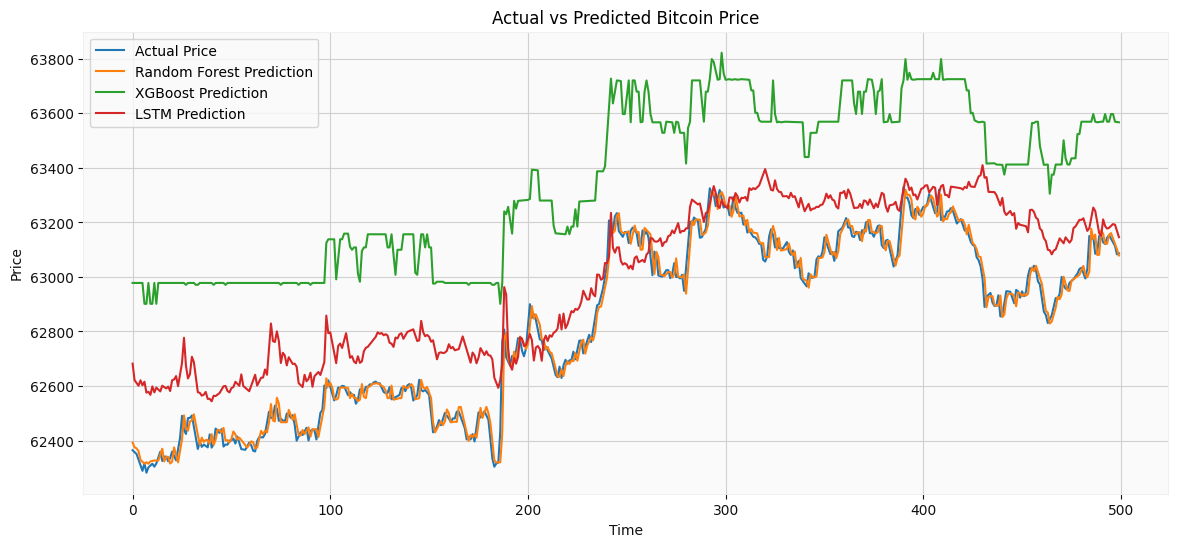

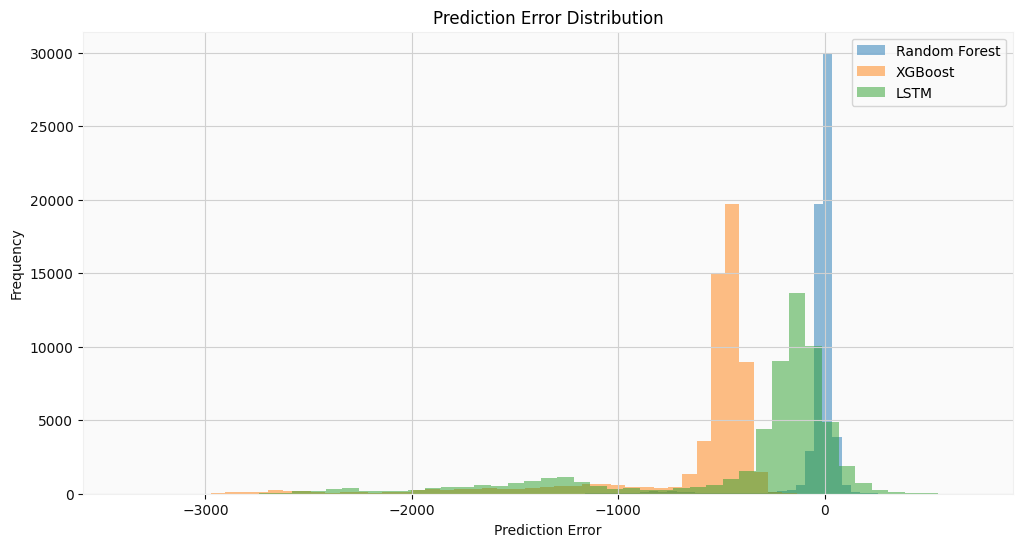

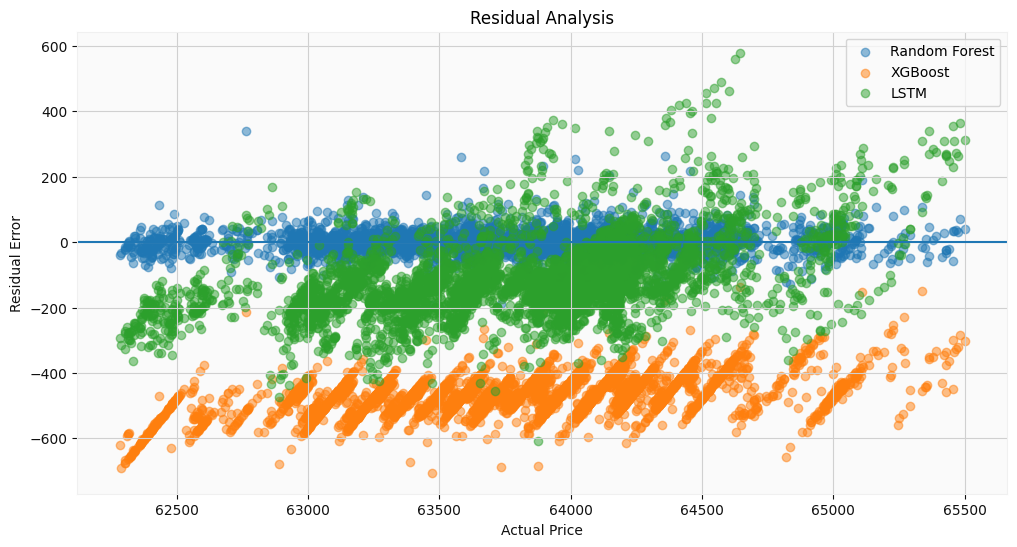

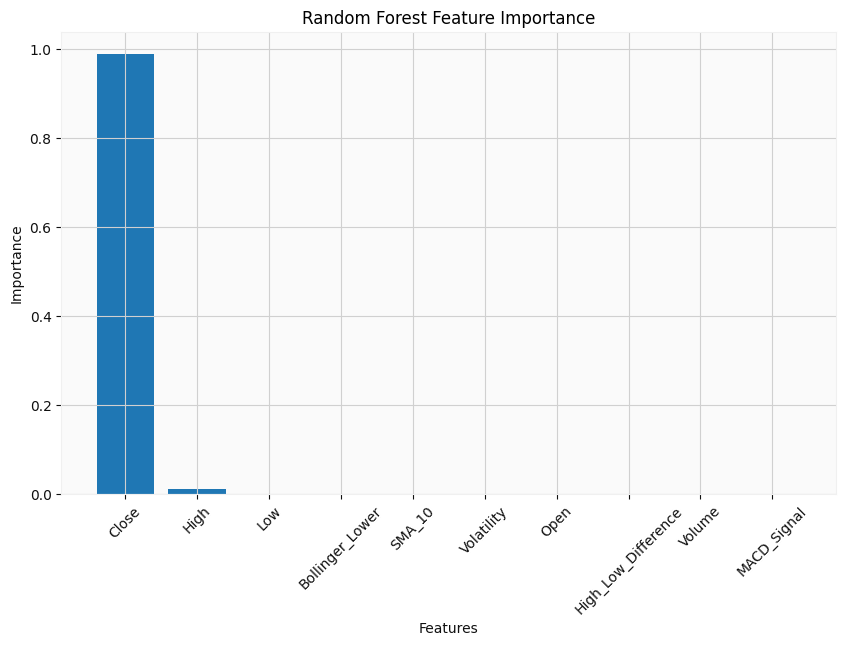

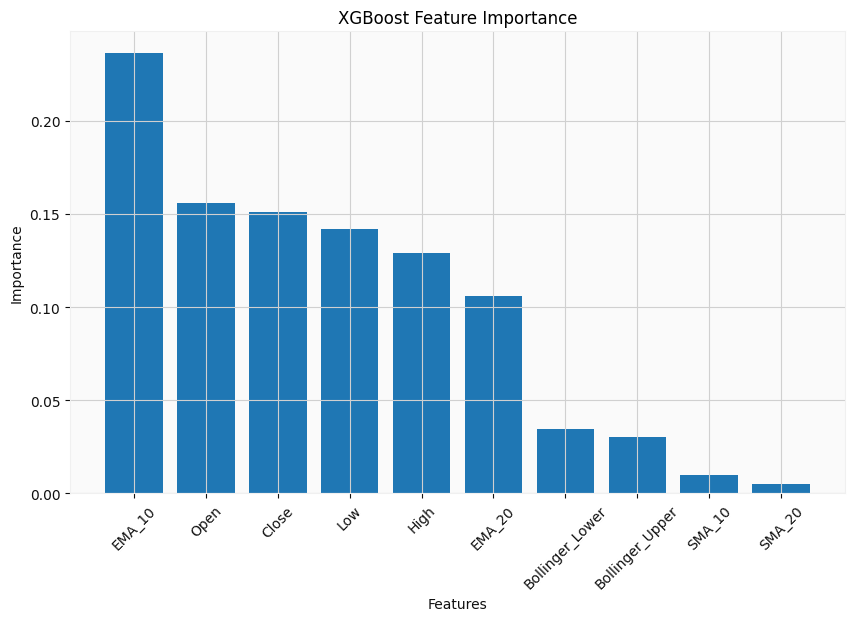

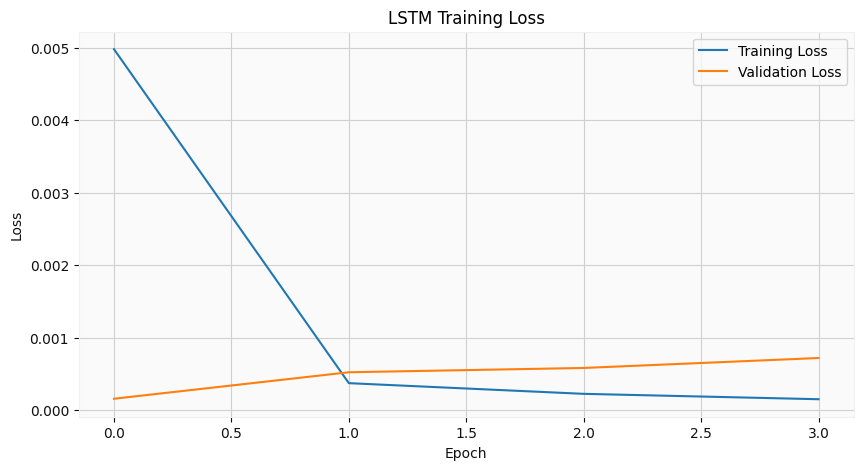

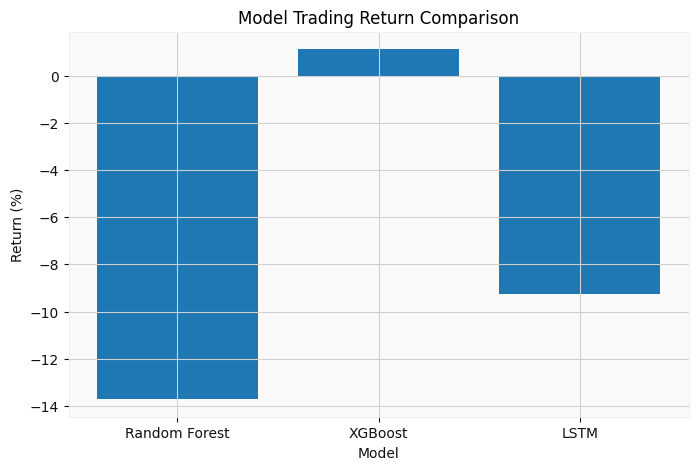

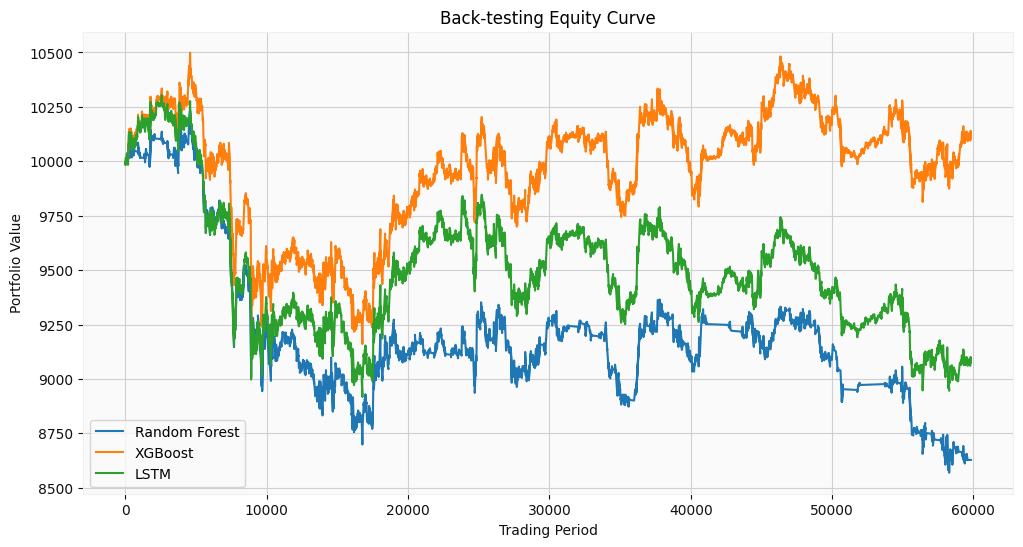

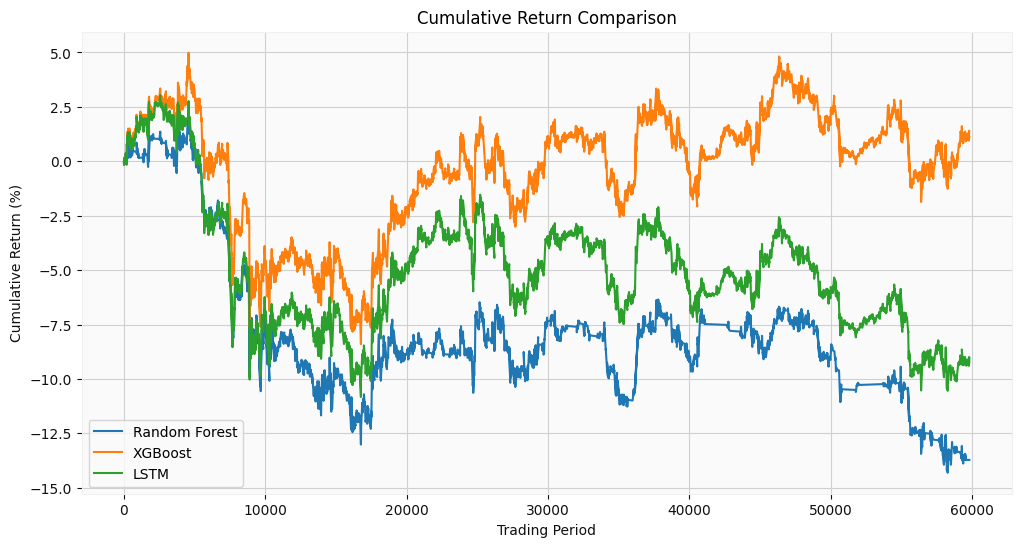

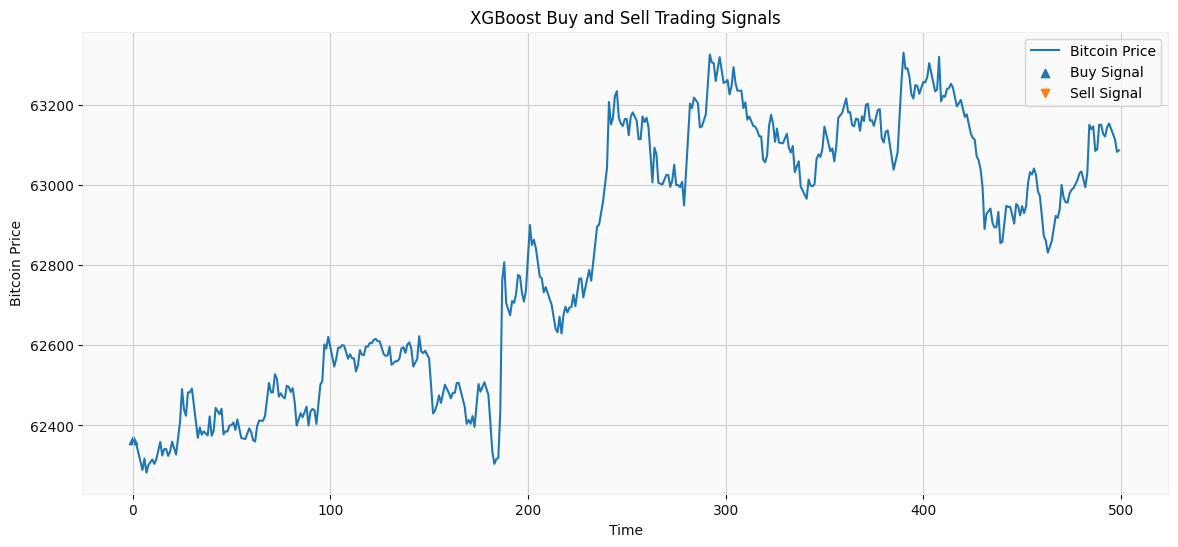

In [83]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


# Prepare actual values

actual_values = backtest["Actual"].values


# Prediction errors

rf_error = actual_values - rf_predictions

xgb_error = actual_values - xgb_predictions

lstm_error = actual_values - lstm_predictions



# Find XGBoost model object

xgb_object = None

if "xgb_model" in globals():
    xgb_object = xgb_model

elif "xgboost_model" in globals():
    xgb_object = xgboost_model

elif "xgb" in globals():
    xgb_object = xgb

else:
    print("XGBoost model object not found")



# 1. Actual vs Predicted Price

plt.figure(figsize=(14,6))

plt.plot(
    actual_values[:500],
    label="Actual Price"
)

plt.plot(
    rf_predictions[:500],
    label="Random Forest Prediction"
)

plt.plot(
    xgb_predictions[:500],
    label="XGBoost Prediction"
)

plt.plot(
    lstm_predictions[:500],
    label="LSTM Prediction"
)

plt.title(
    "Actual vs Predicted Bitcoin Price"
)

plt.xlabel(
    "Time"
)

plt.ylabel(
    "Price"
)

plt.legend()

plt.grid(True)

plt.show()



# 2. Prediction Error Distribution

plt.figure(figsize=(12,6))


plt.hist(
    rf_error,
    bins=50,
    alpha=0.5,
    label="Random Forest"
)


plt.hist(
    xgb_error,
    bins=50,
    alpha=0.5,
    label="XGBoost"
)


plt.hist(
    lstm_error,
    bins=50,
    alpha=0.5,
    label="LSTM"
)


plt.title(
    "Prediction Error Distribution"
)


plt.xlabel(
    "Prediction Error"
)


plt.ylabel(
    "Frequency"
)


plt.legend()

plt.grid(True)

plt.show()



# 3. Residual Plot

plt.figure(figsize=(12,6))


plt.scatter(
    actual_values[:5000],
    rf_error[:5000],
    alpha=0.5,
    label="Random Forest"
)


plt.scatter(
    actual_values[:5000],
    xgb_error[:5000],
    alpha=0.5,
    label="XGBoost"
)


plt.scatter(
    actual_values[:5000],
    lstm_error[:5000],
    alpha=0.5,
    label="LSTM"
)


plt.axhline(
    y=0
)


plt.title(
    "Residual Analysis"
)


plt.xlabel(
    "Actual Price"
)


plt.ylabel(
    "Residual Error"
)


plt.legend()

plt.grid(True)

plt.show()



# 4. Random Forest Feature Importance

rf_importance = pd.DataFrame({

    "Feature": X_train.columns,

    "Importance": random_forest.feature_importances_

})


rf_importance = rf_importance.sort_values(
    by="Importance",
    ascending=False
)


plt.figure(figsize=(10,6))


plt.bar(
    rf_importance["Feature"][:10],
    rf_importance["Importance"][:10]
)


plt.xticks(
    rotation=45
)


plt.title(
    "Random Forest Feature Importance"
)


plt.xlabel(
    "Features"
)


plt.ylabel(
    "Importance"
)


plt.grid(True)

plt.show()



# 5. XGBoost Feature Importance

if xgb_object is not None:

    xgb_importance = pd.DataFrame({

        "Feature": X_train.columns,

        "Importance": xgb_object.feature_importances_

    })


    xgb_importance = xgb_importance.sort_values(
        by="Importance",
        ascending=False
    )


    plt.figure(figsize=(10,6))


    plt.bar(
        xgb_importance["Feature"][:10],
        xgb_importance["Importance"][:10]
    )


    plt.xticks(
        rotation=45
    )


    plt.title(
        "XGBoost Feature Importance"
    )


    plt.xlabel(
        "Features"
    )


    plt.ylabel(
        "Importance"
    )


    plt.grid(True)

    plt.show()



# 6. LSTM Training Loss

plt.figure(figsize=(10,5))


plt.plot(
    history.history["loss"],
    label="Training Loss"
)


plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)


plt.title(
    "LSTM Training Loss"
)


plt.xlabel(
    "Epoch"
)


plt.ylabel(
    "Loss"
)


plt.legend()

plt.grid(True)

plt.show()



# 7. Model Performance Comparison

plt.figure(figsize=(8,5))


plt.bar(
    backtest_results["Model"],
    backtest_results["Return (%)"]
)


plt.title(
    "Model Trading Return Comparison"
)


plt.xlabel(
    "Model"
)


plt.ylabel(
    "Return (%)"
)


plt.grid(True)

plt.show()



# 8. Back-testing Equity Curve

plt.figure(figsize=(12,6))


plt.plot(
    rf_backtest["Equity Curve"],
    label="Random Forest"
)


plt.plot(
    xgb_backtest["Equity Curve"],
    label="XGBoost"
)


plt.plot(
    lstm_backtest["Equity Curve"],
    label="LSTM"
)


plt.title(
    "Back-testing Equity Curve"
)


plt.xlabel(
    "Trading Period"
)


plt.ylabel(
    "Portfolio Value"
)


plt.legend()

plt.grid(True)

plt.show()



# 9. Cumulative Return Comparison


rf_return = (
    np.array(rf_backtest["Equity Curve"])
    /
    initial_balance
    -
    1
) * 100


xgb_return = (
    np.array(xgb_backtest["Equity Curve"])
    /
    initial_balance
    -
    1
) * 100


lstm_return = (
    np.array(lstm_backtest["Equity Curve"])
    /
    initial_balance
    -
    1
) * 100



plt.figure(figsize=(12,6))


plt.plot(
    rf_return,
    label="Random Forest"
)


plt.plot(
    xgb_return,
    label="XGBoost"
)


plt.plot(
    lstm_return,
    label="LSTM"
)


plt.title(
    "Cumulative Return Comparison"
)


plt.xlabel(
    "Trading Period"
)


plt.ylabel(
    "Cumulative Return (%)"
)


plt.legend()

plt.grid(True)

plt.show()



# 10. Buy and Sell Signal Plot

best_model_price = backtest["Actual"].values

best_signals = xgb_backtest["Signals"]


plt.figure(figsize=(14,6))


plt.plot(
    best_model_price[:500],
    label="Bitcoin Price"
)


buy_points = []

sell_points = []


for i, signal in enumerate(best_signals[:500]):

    if signal == "Buy":

        buy_points.append(i)

    elif signal == "Sell":

        sell_points.append(i)



plt.scatter(
    buy_points,
    best_model_price[buy_points],
    marker="^",
    label="Buy Signal"
)


plt.scatter(
    sell_points,
    best_model_price[sell_points],
    marker="v",
    label="Sell Signal"
)


plt.title(
    "XGBoost Buy and Sell Trading Signals"
)


plt.xlabel(
    "Time"
)


plt.ylabel(
    "Bitcoin Price"
)


plt.legend()

plt.grid(True)

plt.show()